In [1]:
# ==========================================================
# scSLAT: Align S3 RNA to S2 ATAC
# ==========================================================

import os
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt

import scSLAT
from scSLAT.model import Cal_Spatial_Net, load_anndatas, run_SLAT, spatial_match
from scSLAT.viz import match_3D_multi

# ==========================================================
# 0) Settings (edit here)
# ==========================================================
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [ ]:
# input data
file_fold_rna = "/mnt/msg/my_file/2024/Dataset/T10-mouse brain/S3/"
file_fold_atac = "/mnt/msg/my_file/2024/Dataset/T10-mouse brain/S2/"
rna_h5ad = "S3-RNA_raw.h5ad"
atac_h5ad = "S2-ATAC_raw.h5ad"

# labels (optional, used for visualization/meta)
rna_label_csv = "S3-RNA-labels.csv"
atac_label_csv = "S2-ATAC-labels.csv"
label_key = "stagate"

# SLAT hyperparams
k_rna = 50
k_atac = 20
lgcn_layer = 6
hidden_size = 4096

# matching / filtering
sim_threshold = 0.65  # cosine similarity threshold for keeping matched pairs

# output
out_dir = "./outputs_slat"
os.makedirs(out_dir, exist_ok=True)

out_rna_matched = os.path.join(out_dir, "S3_RNA_matched.h5ad")
out_rna_full = os.path.join(out_dir, "S3_RNA_reg.h5ad")


In [ ]:
# ==========================================================
# 1) Load data
# ==========================================================
adata_rna = sc.read_h5ad(os.path.join(file_fold_rna, rna_h5ad))
adata_rna.var_names_make_unique()

adata_atac = sc.read_h5ad(os.path.join(file_fold_atac, atac_h5ad))
adata_atac.var_names_make_unique()

if "spatial" not in adata_rna.obsm:
    raise KeyError("adata_rna.obsm['spatial'] not found.")
if "spatial" not in adata_atac.obsm:
    raise KeyError("adata_atac.obsm['spatial'] not found.")


# ==========================================================
# 2) Attach labels (optional)
# ==========================================================
def attach_label_from_csv(adata: sc.AnnData, csv_path: str, *, key: str = "stagate") -> None:
    """
    CSV: index=cell/spot barcodes, one column named `key` (e.g. 'stagate').
    Align by obs_names, fill missing as NaN.
    """
    if not os.path.exists(csv_path):
        print(f"[WARN] label csv not found, skip: {csv_path}")
        return

    df = pd.read_csv(csv_path, index_col=0)
    if key not in df.columns:
        raise KeyError(f"Label column '{key}' not found in {csv_path}. Columns={list(df.columns)}")

    s = df[key].reindex(adata.obs_names)
    adata.obs[key] = s.astype("category")


attach_label_from_csv(adata_rna, os.path.join(file_fold_rna, rna_label_csv), key=label_key)
attach_label_from_csv(adata_atac, os.path.join(file_fold_atac, atac_label_csv), key=label_key)

In [4]:
# ==========================================================
# 3) Preprocess for SLAT (log1p + PCA -> X_glue)
# ==========================================================
sc.pp.log1p(adata_rna)
sc.pp.log1p(adata_atac)

sc.tl.pca(adata_rna, svd_solver="arpack")
sc.tl.pca(adata_atac, svd_solver="arpack")

adata_rna.obsm["X_glue"] = adata_rna.obsm["X_pca"]
adata_atac.obsm["X_glue"] = adata_atac.obsm["X_pca"]

In [5]:
# ==========================================================
# 4) Build spatial graphs
# ==========================================================
Cal_Spatial_Net(adata_rna, k_cutoff=k_rna, model="KNN")
Cal_Spatial_Net(adata_atac, k_cutoff=k_atac, model="KNN")

Calculating spatial neighbor graph ...
The graph contains 485508 edges, 9398 cells.
51.660778889125346 neighbors per cell on average.
Calculating spatial neighbor graph ...
The graph contains 190553 edges, 9223 cells.
20.66063103111786 neighbors per cell on average.


In [6]:
# ==========================================================
# 5) Run SLAT + spatial matching
# ==========================================================
edges, features = load_anndatas([adata_rna, adata_atac], feature="glue")
embd0, embd1, _time = run_SLAT(features, edges, LGCN_layer=lgcn_layer, hidden_size=hidden_size)

best, index, distance = spatial_match([embd0, embd1], adatas=[adata_rna, adata_atac])

best_sim = distance[:, 0].astype(float)

# NOTE:
# We keep EXACT same orientation as your notebook:
# matching[0] -> ATAC indices, matching[1] -> RNA indices
matching = np.array([np.arange(index.shape[0]), best], dtype=np.int64)

Use glue feature to format graph
Choose GPU:2 as device
Running
Training model time: 2.39


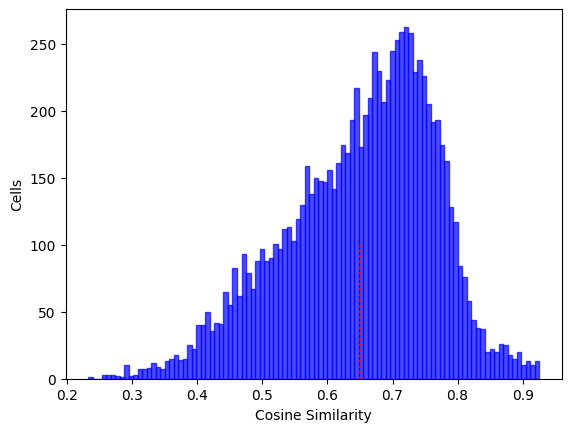

In [ ]:
# ==========================================================
# 6) Filter matches by similarity threshold
# ==========================================================
keep_mask = best_sim > float(sim_threshold)
matching_filter = matching[:, keep_mask]
plt.hist(distance[:,0], bins=100, facecolor="blue", edgecolor="blue", alpha=0.7)
plt.vlines(sim_threshold,0,100,color="red",linestyles='dotted',label='0.9')
plt.xlabel(r'Cosine Similarity')
plt.ylabel(r'Cells')
plt.show()

dataset1: 12 cell types; dataset2: 12 cell types; 
                    Total :12 celltypes; Overlap: 12 cell types 
                    Not overlap :[[]]
Subsampled 300 pairs from 5129


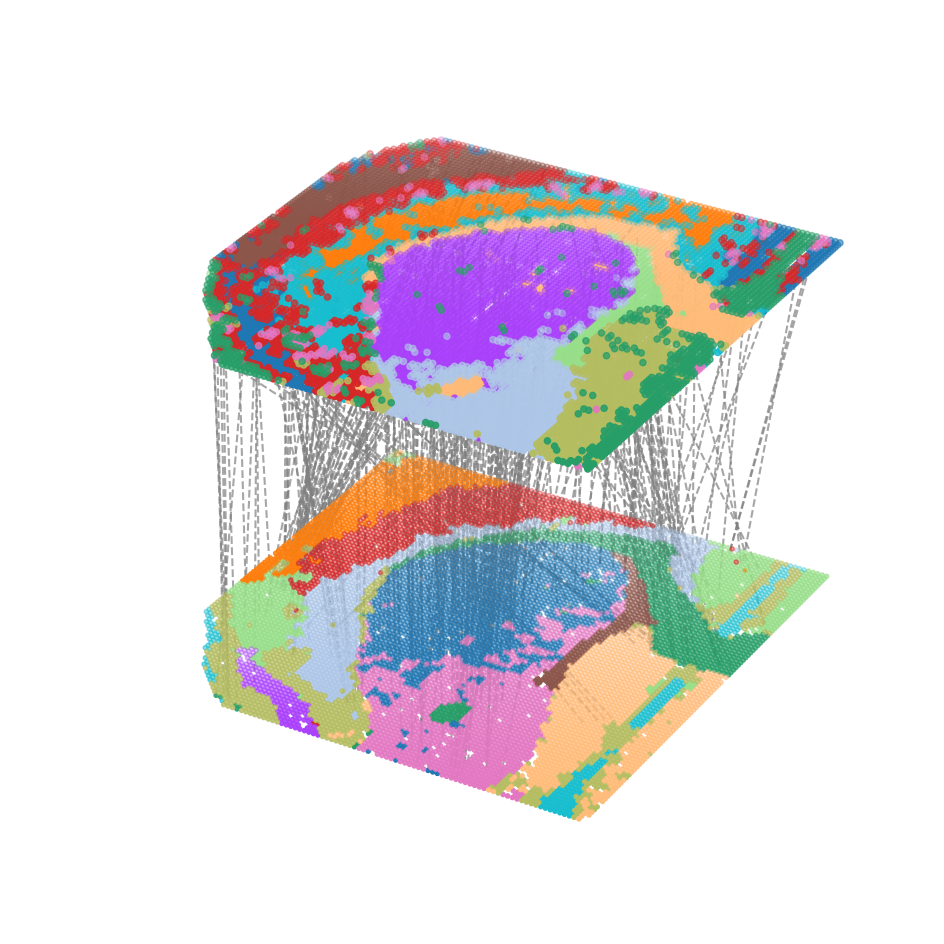

In [11]:
# ==========================================================
# 7) Optional 3D visualization (safe)
# ==========================================================
try:
    adata1_df = pd.DataFrame({
        "index": np.arange(embd0.shape[0]),
        "x": adata_rna.obsm["spatial"][:, 0],
        "y": adata_rna.obsm["spatial"][:, 1],
        label_key: adata_rna.obs[label_key] if label_key in adata_rna.obs.columns else "NA",
    })
    adata2_df = pd.DataFrame({
        "index": np.arange(embd1.shape[0]),
        "x": adata_atac.obsm["spatial"][:, 0],
        "y": adata_atac.obsm["spatial"][:, 1],
        label_key: adata_atac.obs[label_key] if label_key in adata_atac.obs.columns else "NA",
    })

    multi_align = match_3D_multi(
        adata1_df,
        adata2_df,
        matching_filter,
        meta=label_key if label_key in adata_rna.obs.columns else None,
        rotate=["y", "y"],
        scale_coordinate=True,
        subsample_size=300,
    )
    multi_align.draw_3D([12, 12], line_width=1.5, point_size=[9, 20], hide_axis=True, show_error=False)
except Exception as e:
    print(f"[WARN] 3D visualization skipped: {e}")

In [12]:
# ==========================================================
# 8) Build matched-only RNA-on-ATAC AnnData
# ==========================================================
atac_idx = matching_filter[0, :].astype(int)
rna_idx = matching_filter[1, :].astype(int)

atac_filter = adata_atac[atac_idx, :].copy()
rna_filter = adata_rna[rna_idx, :].copy()

adata_rna_new = sc.AnnData(
    X=rna_filter.X,
    obs=atac_filter.obs.copy(),
    var=adata_rna.var.copy(),
)
adata_rna_new.obs_names = atac_filter.obs_names.copy()
adata_rna_new.var_names = adata_rna.var_names.copy()
adata_rna_new.obsm["spatial"] = atac_filter.obsm["spatial"].copy()

adata_rna_new.write_h5ad(out_rna_matched)
print(f"[Saved] matched-only RNA-on-ATAC -> {out_rna_matched}")


/opt/conda/envs/scSLAT/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[Saved] matched-only RNA-on-ATAC -> ./outputs_slat/S3_RNA_matched.h5ad


In [13]:
# ==========================================================
# 9) Build FULL RNA-on-ATAC (pad missing ATAC spots with zeros)
# ==========================================================
atac_all = adata_atac.obs_names
matched_set = set(adata_rna_new.obs_names)

missing_mask = ~atac_all.isin(adata_rna_new.obs_names)
missing_cells = atac_all[missing_mask]  # preserves ATAC order

missing_spatial = adata_atac[missing_cells, :].obsm["spatial"].copy()
missing_X = sp.csr_matrix((len(missing_cells), adata_rna_new.n_vars), dtype=np.float32)

import anndata as ad
missing_adata = ad.AnnData(
    X=missing_X,
    obs=pd.DataFrame(index=missing_cells),
    var=adata_rna_new.var.copy(),
    obsm={"spatial": missing_spatial},
)

adata_rna_new.obs["missing"] = "1"
missing_adata.obs["missing"] = "0"

new_adata_full = ad.concat([adata_rna_new, missing_adata], join="outer", axis=0)
new_adata_full = new_adata_full[atac_all, :].copy()  # strict ATAC order

# ensure float32
if sp.issparse(new_adata_full.X):
    new_adata_full.X = new_adata_full.X.astype(np.float32)
else:
    new_adata_full.X = np.asarray(new_adata_full.X, dtype=np.float32)

new_adata_full.write_h5ad(out_rna_full)
print(f"[Saved] full RNA-on-ATAC (with missing padded) -> {out_rna_full}")

[Saved] full RNA-on-ATAC (with missing padded) -> ./outputs_slat/S3_RNA_S2.h5ad


AnnData object with n_obs × n_vars = 9223 × 22731
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score', 'leiden', 'missing'
    obsm: 'spatial'


/tmp/ipykernel_3164/266631486.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(new_adata_full, color=gene_of_interest, spot_size=35, cmap="viridis", show=True)


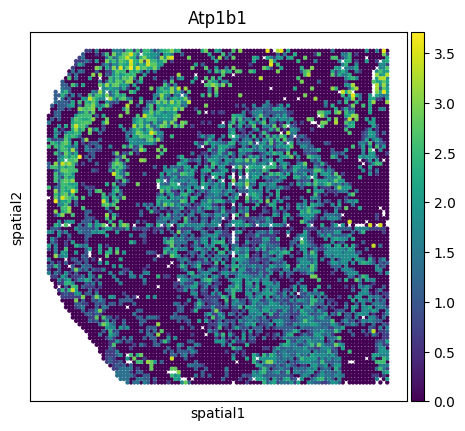

In [28]:
# ==========================================================
# 10) Quick check / optional spatial plot
# ==========================================================
print(new_adata_full)
if new_adata_full.n_vars > 0:
    #gene_of_interest = str(new_adata_full.var_names[985])
    gene_of_interest = "Atp1b1"
    sc.pl.spatial(new_adata_full, color=gene_of_interest, spot_size=35, cmap="viridis", show=True)